<a href="https://colab.research.google.com/github/logonzalezsa/PPAE/blob/main/02_Cuadernos/PPAE_05_Centroide_Momentos_Inercia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROGRAMACIÓN PARA ANÁLISIS DE ESTRUCTURAS

**Universidad Nacional de Colombia – Sede Palmira**  
**Programa Curricular de Ingeniería Agrícola**

### Tema
**Propiedades Geométricas de Secciones Compuestas**

### Taller
**Aplicaciones de Matrices en Ingeniería Estructural**

### Ejercicio
**Determinación del centroide y momentos de inercia de una sección compuesta**

**Elaborado por:**  
Luis Octavio González Salcedo  
Profesor Titular

## 1. Contexto y objetivo

Las propiedades geométricas de una sección transversal son fundamentales en el análisis estructural, ya que intervienen directamente en el estudio de esfuerzos, deformaciones y rigidez de los elementos estructurales.

Cuando una sección está formada por varias figuras geométricas, su análisis puede realizarse dividiéndola en **secciones componentes**. Para cada componente pueden definirse propiedades como:

- coordenadas de su centroide $(X_i,Y_i)$;
- dimensiones geométricas;
- área $A_i$;
- momentos de inercia centroidales $I_{xi}$ e $I_{yi}$.

A partir de esta información es posible determinar inicialmente el centroide de la sección compuesta:

$$
X_c=\frac{\sum A_iX_i}{\sum A_i}
$$

$$
Y_c=\frac{\sum A_iY_i}{\sum A_i}
$$

y posteriormente calcular sus momentos de inercia mediante el **teorema de los ejes paralelos**:

$$
I_{xx}=\sum\left[I_{xi}+A_i(Y_i-Y_c)^2\right]
$$

$$
I_{yy}=\sum\left[I_{yi}+A_i(X_i-X_c)^2\right]
$$

En este ejercicio se desarrollará un algoritmo que permita realizar estos cálculos para una sección compuesta por un número variable de componentes rectangulares.

La información geométrica será organizada matricialmente, de manera que cada fila represente una sección componente y cada columna contenga una de sus propiedades.

El objetivo no consiste únicamente en obtener el centroide y los momentos de inercia, sino en **sistematizar mediante programación un procedimiento de cálculo utilizado en el análisis estructural**.

### 1.1 Convención para áreas llenas y vacíos

Para representar tanto áreas de material como vacíos dentro de una misma matriz se adoptará una convención de signos aplicada a la dimensión de la base $b_i$:

$$
b_i>0 \quad \Rightarrow \quad \text{sección de material}
$$

$$
b_i<0 \quad \Rightarrow \quad \text{vacío}
$$

La altura $h_i$ se ingresará siempre como una magnitud positiva.

Como:

$$
A_i=b_ih_i
$$

un valor negativo de $b_i$ produce automáticamente un área negativa para el vacío.

De igual manera, para una sección rectangular:

$$
I_{xi}=\frac{b_ih_i^3}{12}
$$

$$
I_{yi}=\frac{h_ib_i^3}{12}
$$

los momentos de inercia centroidales asociados con el vacío también adquieren signo negativo.

Esta convención permite incorporar las áreas vacías dentro del mismo procedimiento matemático utilizado para las áreas de material, sin necesidad de desarrollar un algoritmo independiente para ellas.

## 2. Organización matricial de la geometría

La sección compuesta será dividida en $m$ componentes rectangulares.

Para cada componente se ingresarán cinco datos:

$$
i,\quad X_i,\quad Y_i,\quad b_i,\quad h_i
$$

donde:

- $i$ identifica la sección componente;
- $X_i$ es la coordenada horizontal de su centroide;
- $Y_i$ es la coordenada vertical de su centroide;
- $b_i$ es la base del rectángulo;
- $h_i$ es su altura.

Estos datos pueden organizarse mediante una matriz geométrica:

$$
[G]=
\begin{bmatrix}
i & X_i & Y_i & b_i & h_i
\end{bmatrix}
$$

con dimensiones:

$$
[G]_{m\times5}
$$

Cada **fila** representa una sección componente y cada **columna** una propiedad geométrica.

A partir de esta matriz se calcularán posteriormente las áreas, los primeros momentos de área, la posición del centroide y los momentos de inercia de la sección compuesta.

In [1]:
# ============================================================
# DEFINICIÓN DE LA MATRIZ GEOMÉTRICA
# ============================================================

import numpy as np

# Número de componentes de la sección compuesta
m = int(input("Ingrese el número de secciones componentes: "))

# Matriz geométrica:
# columnas -> i, Xi, Yi, bi, hi
G = np.zeros((m, 5), dtype=float)

# Identificación automática de cada componente
G[:, 0] = np.arange(1, m + 1)

print(f"\nLa sección compuesta tendrá {m} componentes.")

print("\nMATRIZ GEOMÉTRICA [G]")
print("---------------------")
print(G)

print("\nDimensiones de [G]:", G.shape)

Ingrese el número de secciones componentes: 5

La sección compuesta tendrá 5 componentes.

MATRIZ GEOMÉTRICA [G]
---------------------
[[1. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0.]
 [3. 0. 0. 0. 0.]
 [4. 0. 0. 0. 0.]
 [5. 0. 0. 0. 0.]]

Dimensiones de [G]: (5, 5)


### 2.1 Ingreso de los componentes geométricos

Los datos geométricos de cada sección componente se ingresarán siguiendo el orden:

$$
X_i \qquad Y_i \qquad b_i \qquad h_i
$$

El identificador $i$ será asignado automáticamente por el programa.

Para cada componente deben ingresarse exactamente cuatro valores numéricos separados por espacios.

Cuando una sección corresponda a un vacío, la base $b_i$ deberá introducirse con signo negativo, de acuerdo con la convención establecida anteriormente.

Después de ingresar cada componente se mostrará la matriz geométrica actualizada, permitiendo verificar los datos antes de continuar con los cálculos.

In [2]:
# ============================================================
# INGRESO DE LOS COMPONENTES GEOMÉTRICOS
# ============================================================

for i in range(m):

    print("\n" + "=" * 60)
    print(f"SECCIÓN COMPONENTE {i + 1}")
    print("=" * 60)

    print("\nIngrese los datos en el siguiente orden:")
    print("Xi   Yi   bi   hi")

    while True:

        entrada = input("\nIngrese los 4 valores separados por espacios: ")

        try:
            datos = [float(x) for x in entrada.split()]

            if len(datos) == 4:
                break
            else:
                print(
                    f"\nDebe ingresar exactamente 4 valores. "
                    f"Se ingresaron {len(datos)}."
                )

        except ValueError:
            print("\nTodos los datos deben ser valores numéricos.")

    # Almacenar Xi, Yi, bi y hi
    G[i, 1:] = datos

    print("\nMATRIZ GEOMÉTRICA [G] ACTUALIZADA")
    print("---------------------------------")
    print(G)


SECCIÓN COMPONENTE 1

Ingrese los datos en el siguiente orden:
Xi   Yi   bi   hi

Ingrese los 4 valores separados por espacios: 1.5 3.5 3 7

MATRIZ GEOMÉTRICA [G] ACTUALIZADA
---------------------------------
[[1.  1.5 3.5 3.  7. ]
 [2.  0.  0.  0.  0. ]
 [3.  0.  0.  0.  0. ]
 [4.  0.  0.  0.  0. ]
 [5.  0.  0.  0.  0. ]]

SECCIÓN COMPONENTE 2

Ingrese los datos en el siguiente orden:
Xi   Yi   bi   hi

Ingrese los 4 valores separados por espacios: 4.5 5.5 3 3

MATRIZ GEOMÉTRICA [G] ACTUALIZADA
---------------------------------
[[1.  1.5 3.5 3.  7. ]
 [2.  4.5 5.5 3.  3. ]
 [3.  0.  0.  0.  0. ]
 [4.  0.  0.  0.  0. ]
 [5.  0.  0.  0.  0. ]]

SECCIÓN COMPONENTE 3

Ingrese los datos en el siguiente orden:
Xi   Yi   bi   hi

Ingrese los 4 valores separados por espacios: 9 3.5 6 7

MATRIZ GEOMÉTRICA [G] ACTUALIZADA
---------------------------------
[[1.  1.5 3.5 3.  7. ]
 [2.  4.5 5.5 3.  3. ]
 [3.  9.  3.5 6.  7. ]
 [4.  0.  0.  0.  0. ]
 [5.  0.  0.  0.  0. ]]

SECCIÓN COMPONENTE 4

I

## 3. Cálculo de áreas y primeros momentos de área

A partir de la matriz geométrica $[G]$ se extraen las propiedades de cada sección componente:

$$
X_i,\qquad Y_i,\qquad b_i,\qquad h_i
$$

Para cada componente se calcula su área:

$$
A_i=b_ih_i
$$

y sus primeros momentos de área respecto a los ejes de referencia:

$$
A_iX_i
$$

$$
A_iY_i
$$

La suma de las áreas permite obtener el área neta de la sección compuesta:

$$
A=\sum_{i=1}^{m}A_i
$$

mientras que las coordenadas de su centroide se determinan mediante:

$$
X_c=\frac{\sum A_iX_i}{\sum A_i}
$$

$$
Y_c=\frac{\sum A_iY_i}{\sum A_i}
$$

Las áreas correspondientes a vacíos participan automáticamente con signo negativo debido a la convención adoptada para $b_i$.

In [3]:
# ============================================================
# ÁREAS Y PRIMEROS MOMENTOS DE ÁREA
# ============================================================

# Extraer las columnas de la matriz geométrica
Xi = G[:, 1]
Yi = G[:, 2]
bi = G[:, 3]
hi = G[:, 4]

# Calcular áreas
Ai = bi * hi

# Primeros momentos de área
AiXi = Ai * Xi
AiYi = Ai * Yi

# Sumatorias
A_total = np.sum(Ai)
suma_AiXi = np.sum(AiXi)
suma_AiYi = np.sum(AiYi)

# Coordenadas del centroide
Xc = suma_AiXi / A_total
Yc = suma_AiYi / A_total

print("RESULTADOS POR SECCIÓN COMPONENTE")
print("=================================")

for i in range(m):
    print(
        f"Sección {i+1}: "
        f"A = {Ai[i]:10.4f}   "
        f"A·X = {AiXi[i]:10.4f}   "
        f"A·Y = {AiYi[i]:10.4f}"
    )

print("\nSUMATORIAS")
print("==========")
print(f"ΣA     = {A_total:.4f}")
print(f"Σ(A·X) = {suma_AiXi:.4f}")
print(f"Σ(A·Y) = {suma_AiYi:.4f}")

print("\nCENTROIDE DE LA SECCIÓN COMPUESTA")
print("=================================")
print(f"Xc = {Xc:.4f}")
print(f"Yc = {Yc:.4f}")

RESULTADOS POR SECCIÓN COMPONENTE
Sección 1: A =    21.0000   A·X =    31.5000   A·Y =    73.5000
Sección 2: A =     9.0000   A·X =    40.5000   A·Y =    49.5000
Sección 3: A =    42.0000   A·X =   378.0000   A·Y =   147.0000
Sección 4: A =   -20.0000   A·X =  -180.0000   A·Y =   -70.0000
Sección 5: A =     6.0000   A·X =    81.0000   A·Y =    36.0000

SUMATORIAS
ΣA     = 58.0000
Σ(A·X) = 351.0000
Σ(A·Y) = 236.0000

CENTROIDE DE LA SECCIÓN COMPUESTA
Xc = 6.0517
Yc = 4.0690


## 4. Momentos de inercia de la sección compuesta

Una vez determinadas las coordenadas del centroide de la sección compuesta $(X_c,Y_c)$, se calculan las distancias entre el centroide de cada componente y el centroide global:

$$
D_{ix}=X_i-X_c
$$

$$
D_{iy}=Y_i-Y_c
$$

Para cada componente rectangular, los momentos de inercia respecto a sus propios ejes centroidales son:

$$
I_{xi}=\frac{b_i h_i^3}{12}
$$

$$
I_{yi}=\frac{h_i b_i^3}{12}
$$

Mediante el teorema de los ejes paralelos, la contribución de cada componente respecto a los ejes centroidales de la sección compuesta es:

$$
I_{xx,i}=I_{xi}+A_iD_{iy}^{2}
$$

$$
I_{yy,i}=I_{yi}+A_iD_{ix}^{2}
$$

Finalmente:

$$
I_{xx}=\sum_{i=1}^{m}I_{xx,i}
$$

$$
I_{yy}=\sum_{i=1}^{m}I_{yy,i}
$$

Debido a la convención adoptada, los vacíos poseen área y momentos de inercia negativos, por lo cual sus contribuciones se restan automáticamente de las propiedades de la sección compuesta.

In [4]:
# ============================================================
# MOMENTOS DE INERCIA DE LA SECCIÓN COMPUESTA
# ============================================================

# Distancias desde cada centroide al centroide global
Dix = Xi - Xc
Diy = Yi - Yc

# Momentos de inercia centroidales de cada rectángulo
Ixi = bi * hi**3 / 12
Iyi = hi * bi**3 / 12

# Teorema de los ejes paralelos
Ixx_i = Ixi + Ai * Diy**2
Iyy_i = Iyi + Ai * Dix**2

# Momentos de inercia de la sección compuesta
Ixx = np.sum(Ixx_i)
Iyy = np.sum(Iyy_i)

print("CONTRIBUCIÓN DE CADA SECCIÓN COMPONENTE")
print("========================================")

for i in range(m):

    print(f"\nSección {i+1}")

    print(f"Dix   = {Dix[i]:10.4f}")
    print(f"Diy   = {Diy[i]:10.4f}")

    print(f"Ixi   = {Ixi[i]:10.4f}")
    print(f"Iyi   = {Iyi[i]:10.4f}")

    print(f"Ixx_i = {Ixx_i[i]:10.4f}")
    print(f"Iyy_i = {Iyy_i[i]:10.4f}")


print("\nMOMENTOS DE INERCIA DE LA SECCIÓN COMPUESTA")
print("============================================")
print(f"Ixx = {Ixx:.4f}")
print(f"Iyy = {Iyy:.4f}")

CONTRIBUCIÓN DE CADA SECCIÓN COMPONENTE

Sección 1
Dix   =    -4.5517
Diy   =    -0.5690
Ixi   =    85.7500
Iyi   =    15.7500
Ixx_i =    92.5482
Iyy_i =   450.8320

Sección 2
Dix   =    -1.5517
Diy   =     1.4310
Ixi   =     6.7500
Iyi   =     6.7500
Ixx_i =    25.1807
Iyy_i =    28.4206

Sección 3
Dix   =     2.9483
Diy   =    -0.5690
Ixi   =   171.5000
Iyi   =   126.0000
Ixx_i =   185.0963
Iyy_i =   491.0779

Sección 4
Dix   =     2.9483
Diy   =    -0.5690
Ixi   =   -41.6667
Iyi   =   -26.6667
Ixx_i =   -48.1411
Iyy_i =  -200.5133

Sección 5
Dix   =     7.4483
Diy   =     1.9310
Ixi   =     2.0000
Iyi   =     4.5000
Ixx_i =    24.3734
Iyy_i =   337.3609

MOMENTOS DE INERCIA DE LA SECCIÓN COMPUESTA
Ixx = 279.0575
Iyy = 1107.1782


In [5]:
# ============================================================
# TABLA RESUMEN DE PROPIEDADES GEOMÉTRICAS
# ============================================================

import pandas as pd

tabla = pd.DataFrame({
    "Sección": np.arange(1, m + 1),
    "Xi": Xi,
    "Yi": Yi,
    "bi": bi,
    "hi": hi,
    "Ai": Ai,
    "Ai·Xi": AiXi,
    "Ai·Yi": AiYi,
    "Dix": Dix,
    "Diy": Diy,
    "Ixi": Ixi,
    "Iyi": Iyi,
    "Ixx_i": Ixx_i,
    "Iyy_i": Iyy_i
})

display(tabla.round(4))

print("\nPROPIEDADES DE LA SECCIÓN COMPUESTA")
print("====================================")
print(f"Área neta = {A_total:.4f}")
print(f"Xc        = {Xc:.4f}")
print(f"Yc        = {Yc:.4f}")
print(f"Ixx       = {Ixx:.4f}")
print(f"Iyy       = {Iyy:.4f}")

,Sección,Xi,Yi,bi,hi,Ai,Ai·Xi,Ai·Yi,Dix,Diy,Ixi,Iyi,Ixx_i,Iyy_i
0,1,1.5,3.5,3.0,7.0,21.0,31.5,73.5,-4.5517,-0.569,85.7500,15.7500,92.5482,450.8320
1,2,4.5,5.5,3.0,3.0,9.0,40.5,49.5,-1.5517,1.431,6.7500,6.7500,25.1807,28.4206
2,3,9.0,3.5,6.0,7.0,42.0,378.0,147.0,2.9483,-0.569,171.5000,126.0000,185.0963,491.0779
3,4,9.0,3.5,-4.0,5.0,-20.0,-180.0,-70.0,2.9483,-0.569,-41.6667,-26.6667,-48.1411,-200.5133
4,5,13.5,6.0,3.0,2.0,6.0,81.0,36.0,7.4483,1.931,2.0000,4.5000,24.3734,337.3609



PROPIEDADES DE LA SECCIÓN COMPUESTA
Área neta = 58.0000
Xc        = 6.0517
Yc        = 4.0690
Ixx       = 279.0575
Iyy       = 1107.1782


## 5. Representación gráfica de la sección compuesta

Además de obtener numéricamente las propiedades geométricas, resulta conveniente representar la sección transversal y localizar gráficamente su centroide.

Cada componente rectangular será dibujado a partir de las coordenadas de su centroide $(X_i,Y_i)$ y de sus dimensiones $b_i$ y $h_i$.

Las secciones de material y los vacíos se identificarán de manera diferente de acuerdo con el signo adoptado para $b_i$.

Finalmente, se representará el centroide de la sección compuesta:

$$
C(X_c,Y_c)
$$

La representación gráfica constituye una herramienta adicional para verificar la coherencia geométrica de los datos ingresados y de los resultados obtenidos.

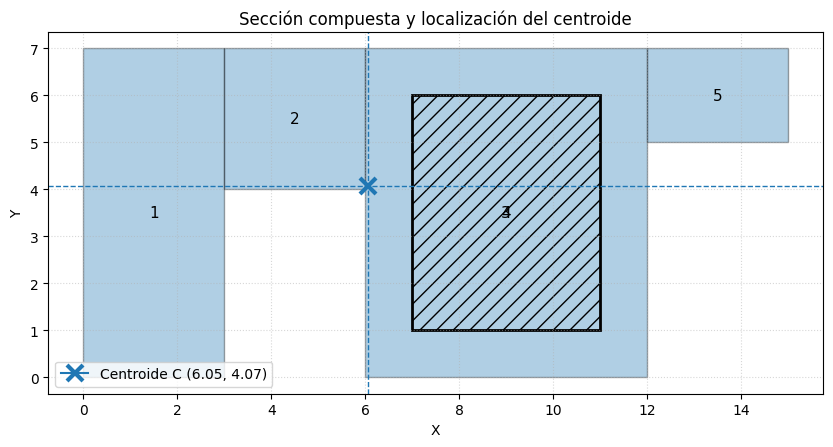

In [6]:
# ============================================================
# REPRESENTACIÓN GRÁFICA DE LA SECCIÓN COMPUESTA
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(m):

    # Dimensiones geométricas
    ancho = abs(bi[i])
    alto = hi[i]

    # Esquina inferior izquierda del rectángulo
    x0 = Xi[i] - ancho / 2
    y0 = Yi[i] - alto / 2

    # Diferenciar material y vacío
    if bi[i] > 0:

        rectangulo = Rectangle(
            (x0, y0),
            ancho,
            alto,
            alpha=0.35,
            edgecolor="black"
        )

        tipo = "Material"

    else:

        rectangulo = Rectangle(
            (x0, y0),
            ancho,
            alto,
            fill=False,
            edgecolor="black",
            hatch="//",
            linewidth=2
        )

        tipo = "Vacío"

    ax.add_patch(rectangulo)

    # Identificación del componente
    ax.text(
        Xi[i],
        Yi[i],
        f"{i+1}",
        ha="center",
        va="center",
        fontsize=11
    )

# ------------------------------------------------------------
# CENTROIDE DE LA SECCIÓN COMPUESTA
# ------------------------------------------------------------

ax.plot(
    Xc,
    Yc,
    marker="x",
    markersize=12,
    markeredgewidth=3,
    label=f"Centroide C ({Xc:.2f}, {Yc:.2f})"
)

# Líneas auxiliares por el centroide
ax.axvline(Xc, linestyle="--", linewidth=1)
ax.axhline(Yc, linestyle="--", linewidth=1)

# ------------------------------------------------------------
# PRESENTACIÓN DEL GRÁFICO
# ------------------------------------------------------------

ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title(
    "Sección compuesta y localización del centroide"
)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()

plt.show()

## 6. Reflexión final

La determinación de las propiedades geométricas de una sección compuesta puede convertirse rápidamente en un procedimiento extenso cuando aumenta el número de componentes que la conforman. Sin embargo, el fundamento matemático permanece invariable.

En este ejercicio, la geometría de la sección fue organizada mediante una matriz:

$$
[G]=
\begin{bmatrix}
i & X_i & Y_i & b_i & h_i
\end{bmatrix}
$$

en la cual cada fila representa una sección componente y cada columna contiene una de sus características geométricas.

A partir de esta información fue posible desarrollar sistemáticamente la secuencia:

$$
\boxed{
\text{Geometría}
\rightarrow
[G]
\rightarrow
A_i
\rightarrow
(X_c,Y_c)
\rightarrow
(D_{ix},D_{iy})
\rightarrow
(I_{xi},I_{yi})
\rightarrow
(I_{xx},I_{yy})
}
$$

La utilización de valores negativos para representar los vacíos permitió incorporar áreas llenas y vacías dentro de un mismo procedimiento matemático. De esta manera, el signo asociado con la geometría se propagó automáticamente hacia las áreas, los primeros momentos de área y los momentos de inercia, sin necesidad de desarrollar algoritmos independientes para cada caso.

El teorema de los ejes paralelos permitió posteriormente trasladar los momentos de inercia de cada componente hacia los ejes centroidales de la sección compuesta:

$$
I_{xx}=\sum\left[I_{xi}+A_i(Y_i-Y_c)^2\right]
$$

$$
I_{yy}=\sum\left[I_{yi}+A_i(X_i-X_c)^2\right]
$$

La comparación de los resultados obtenidos mediante el algoritmo con los calculados previamente mediante una hoja dinámica permitió verificar la implementación computacional del procedimiento.

Adicionalmente, la representación gráfica de la sección permitió comprobar visualmente la disposición de sus componentes y la localización del centroide. Esta verificación resulta especialmente importante, ya que un programa puede ejecutar correctamente las operaciones indicadas aun cuando los datos geométricos hayan sido ingresados incorrectamente.

El algoritmo desarrollado tampoco está limitado a la sección utilizada como ejemplo. Al trabajar con un número variable de componentes, el mismo procedimiento puede aplicarse a diferentes configuraciones geométricas siempre que estas puedan representarse mediante las propiedades definidas en la matriz de entrada.

En consecuencia, la programación permite transformar un procedimiento repetitivo de cálculo en un algoritmo general, manteniendo visibles los fundamentos matemáticos y estructurales que lo sustentan.

> **Programar las propiedades de una sección no consiste en reemplazar sus ecuaciones; consiste en organizar la geometría para que esas ecuaciones puedan aplicarse sistemáticamente.**